## Visulising the input space division by relu

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
class ReLUNetwork:
  def __init__(self, layer_sizes):
    self.weights = []
    self.biases = []
    self.layer_sizes = layer_sizes

    np.random.seed(32)
    for i in range(len(self.layer_sizes)-1):
      #He initialization
      scale = np.sqrt(2.0 / self.layer_sizes[i])
      W = np.random.randn(self.layer_sizes[i+1], self.layer_sizes[i]) * scale
      b = np.random.randn(self.layer_sizes[i+1]) * 0.1
      self.weights.append(W)
      self.biases.append(b)

  def get_binary_vector(self, x):
    activation = x
    binary_code = []

    for i in range(len(self.weights)-1):
      W = self.weights[i]
      b = self.biases[i]
      z = np.dot(W, activation) + b

      layer_bits = (z>0).astype(int)
      binary_code.extend(layer_bits)

      #apply ReLU for next layer
      activation = np.maximum(0, z)
    return tuple(binary_code), activation

In [ ]:
from enum import unique
def visulaize_polyhedra(net, x_min=-2, x_max=2, resolution = 400):
  xx, yy = np.meshgrid(
      np.linspace(x_min, x_max, resolution),
      np.linspace(x_min, x_max, resolution),
    )

  grid_points = np.c_[xx.ravel(), yy.ravel()]

  signatures = []
  for point in grid_points:
    sig, _ = net.get_binary_vector(point)
    signatures.append(sig)

  unique_sigs = list(set(signatures))
  sig_map = {sig : i for  i, sig in enumerate(unique_sigs)}

  z_values = np.array([sig_map[s] for s in signatures])
  z_values = z_values.reshape(xx.shape)

  plt.figure(figsize = (10, 10))
  plt.imshow(
      z_values,
      extent=(x_min, x_max, x_min, x_max),
      origin='lower',
      cmap = 'tab20b',
      interpolation = 'nearest'
    )
  plt.title(f"Polyhedron Decomposition \n {len(unique_sigs)} unique regions identified", fontsize=15)
  plt.xlabel("input_dimension 1")
  plt.ylabel("input_dimension 2")
  plt.colorbar(label = 'polyhedron ID')
  plt.show()

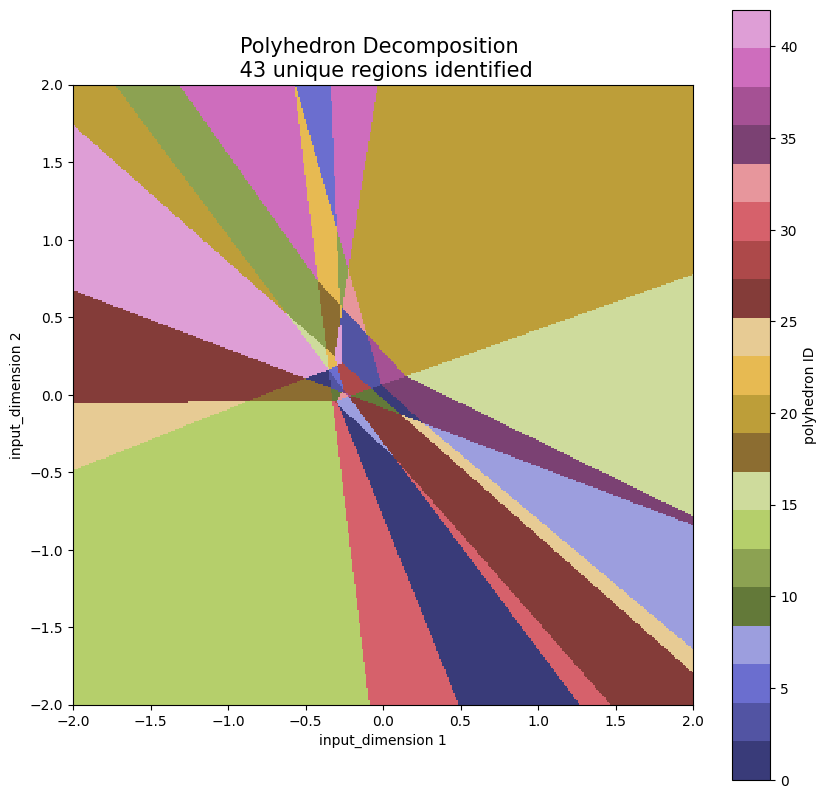

In [ ]:
net = ReLUNetwork([2, 5, 5,1])

visulaize_polyhedra(net)

#Manifold Detection experiment

In [ ]:
from scipy.spatial.distance import pdist, squareform

def generate_circle_data(n_points = 100, radius = 1.0, noise = 0.05):
  t  = np.linspace(0, 2*np.pi, n_points)

  x = radius * np.cos(t)
  y = radius * np.sin(t)

  data = np.c_[x,y] + np.random.randn(n_points, 2)*noise
  return data

In [ ]:
def get_hamming_matrix(net, data):
  signatures= []
  for point in data:
    sig, _ = net.get_binary_vector(point)
    signatures.append(sig)
  signatures = np.array(signatures)

  dists = pdist(signatures, metric = 'hamming') * signatures.shape[1]
  return squareform(dists)

In [ ]:
deep_net = ReLUNetwork([2, 50,100, 50, 1])
circle_data = generate_circle_data(n_points=100)

hamming_matrix = get_hamming_matrix(deep_net, circle_data)
euclidean_matrix = squareform(pdist(circle_data, metric='euclidean'))

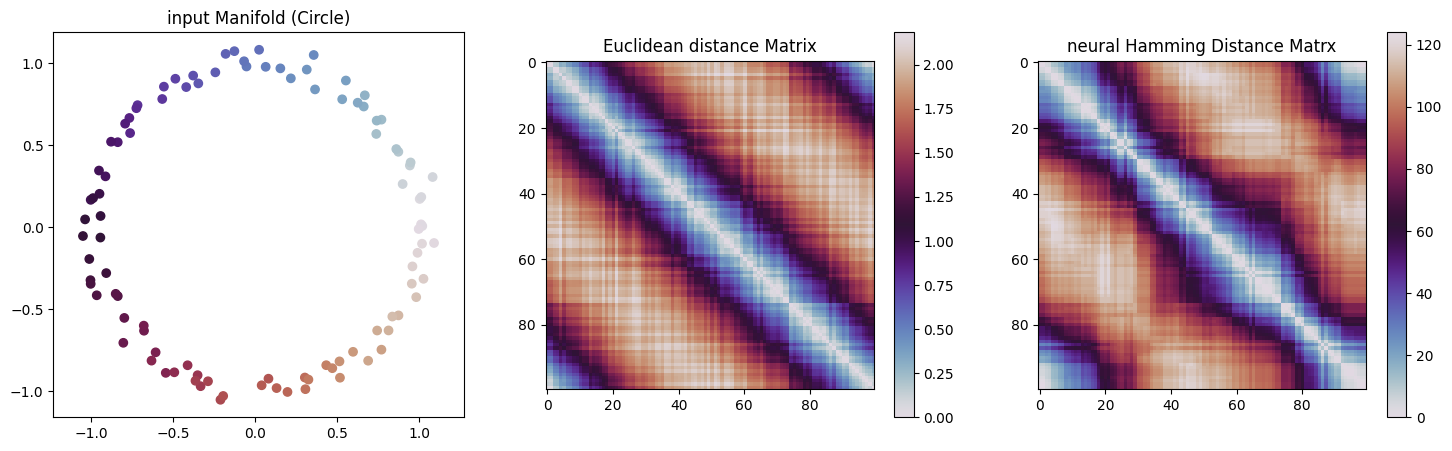

In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (18, 5))
axes[0].scatter(circle_data[:,0], circle_data[:,1], c=np.arange(len(circle_data)), cmap='twilight')
axes[0].set_title("input Manifold (Circle)")
axes[0].axis("equal")

im1 = axes[1].imshow(euclidean_matrix, cmap = 'twilight')
axes[1].set_title("Euclidean distance Matrix")
plt.colorbar(im1, ax = axes[1])

im2 = axes[2].imshow(hamming_matrix, cmap='twilight')
axes[2].set_title("neural Hamming Distance Matrx")
plt.colorbar(im2, ax = axes[2])

plt.show()

# Visualise Dual Graph

In [ ]:
from inspect import signature
import networkx as nx

def build_dual_graph(net, x_min=-2, x_max=2, resolution=50):
  xx, yy = np.meshgrid(
      np.linspace(x_min, x_max, resolution),
      np.linspace(x_min, x_max, resolution)
  )

  grid_points = np.c_[xx.ravel(), yy.ravel()]

  unique_sig = set()

  for point in grid_points:
    sig, _ = net.get_binary_vector(point)
    unique_sig.add(sig)

  unique_sig = list(unique_sig)

  G = nx.Graph()

  for i, sig in enumerate(unique_sig):
    G.add_node(i, signature=sig)

  for i in range(len(unique_sig)):
    for j in range(i+1, len(unique_sig)):
      diff = sum(b1 != b2 for b1,b2 in zip(unique_sig[i], unique_sig[j]))
      if diff == 1:
        G.add_edge(i,j)
  return G


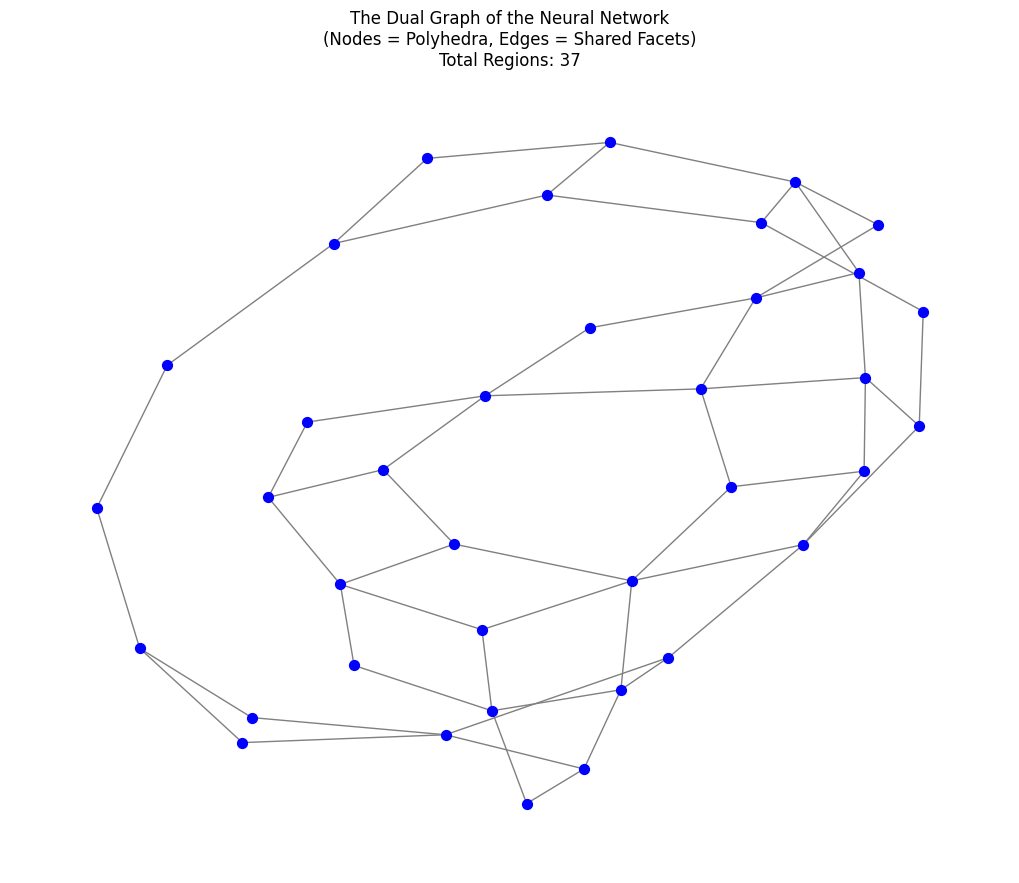

In [ ]:
small_net = ReLUNetwork([2, 5, 5, 1])
G = build_dual_graph(small_net)

plt.figure(figsize=(10,8))
pos = nx.spring_layout(G, seed = 42)
nx.draw(G, pos, node_size = 50, node_color='blue', edge_color = 'gray', with_labels = False)
plt.title(f"The Dual Graph of the Neural Network\n(Nodes = Polyhedra, Edges = Shared Facets)\nTotal Regions: {len(G.nodes)}")
plt.show()

In [ ]:
!pip install ripser persim

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 4.2 MB/s eta 0:00:00
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18104 sha256=d62db303bc087f544811c79976df7757e335be72308019fa604811b9c3a6d2b7
  Stored in directory: /root/.cache/pip/wheels/2a/fd/fe/f4b8fd82894e1d9e04040ef41dc5ae6eb7a8e9b0ef5a9402fe
Successfully built hopcroftkarp


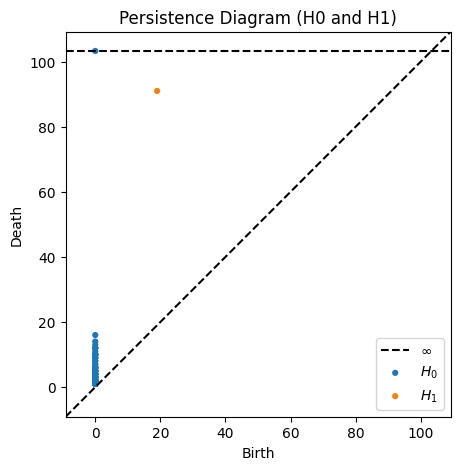

In [ ]:
from ripser import ripser
from persim import plot_diagrams

result = ripser(hamming_matrix, distance_matrix=True, maxdim=1)
diagrams = result['dgms']

plt.figure(figsize=(10, 5))
plot_diagrams(diagrams, show=True, title="Persistence Diagram (H0 and H1)")

# H0 (Blue) = Connected Components
# H1 (Orange) = Loops

In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

# 1. Load Pre-trained ResNet-50
resnet = models.resnet50(pretrained=True)
resnet.eval()

# 2. Create a Hook to Capture Bits
# We will store the binary vectors here
binary_bits = []

def get_relu_bits(module, input, output):
    # 'output' is the result of the ReLU layer
    # We turn it into bits: 1 if > 0, else 0
    bits = (output > 0).float()
    # Flatten and store
    binary_bits.append(bits.flatten().detach().numpy())

# 3. Register Hook on all ReLU layers
# ResNet uses distinct ReLU layers, so we iterate and attach the hook
hooks = []
for name, layer in resnet.named_modules():
    if isinstance(layer, torch.nn.ReLU):
        hooks.append(layer.register_forward_hook(get_relu_bits))

# 4. Run a Real Image
# (Load a cat image or random noise)
input_image = torch.randn(1, 3, 224, 224) # Dummy image for demo

# Clear previous bits
binary_bits = []
with torch.no_grad():
    _ = resnet(input_image)

# 5. Analyze
total_bits = sum(len(b) for b in binary_bits)
print(f"Total ReLU neurons (bits) in ResNet-50: {total_bits}")
# Expected: ~10-11 million bits depending on implementation specifics

# Concatenate into one massive binary vector
full_signature = np.concatenate(binary_bits)
print(f"Signature Shape: {full_signature.shape}")

# Cleanup hooks
for h in hooks: h.remove()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 130MB/s]


Total ReLU neurons (bits) in ResNet-50: 9608704
Signature Shape: (9608704,)
